## Data Ingestion

In [162]:
#Core Libraries
import pandas as pd
import polars as pl
import numpy as np

import joblib
import shap
import os

import matplotlib.pyplot as plt

# Scikit-learn: Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

#Scikit-learn: Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

#Scikit-learn: Metrics
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report,
    make_scorer, accuracy_score, f1_score, roc_auc_score,
    roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay,
    confusion_matrix
)

# Scikit-learn: Model Selection & Evaluation
from sklearn.model_selection import (
    train_test_split,
)

# Torch For Neural Networks
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [5]:
#Loading in the cleaned data
try:
    taxi_trip_df = pl.read_parquet("data/cleaned-taxi-data.parquet")
    taxi_zone_df = pl.read_csv("data/taxi_zone_lookup.csv")
except Exception as e:
    print("Error: ", e)

#Filtering to only use rows with credit card payment
taxi_trip_df = taxi_trip_df.filter(pl.col("payment_type") == 1)

print("Taxi Data Df")
taxi_trip_df.head()

Taxi Data Df


VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0
1,2024-01-01 00:54:08,2024-01-01 01:26:31,1,4.7,1,"""N""",148,141,1,29.6,3.5,0.5,6.9,0.0,1.0,41.5,2.5,0.0


In [6]:
print("Taxi Zone Df")
taxi_zone_df.head()

Taxi Zone Df


LocationID,Borough,Zone,service_zone
i64,str,str,str
1,"""EWR""","""Newark Airport""","""EWR"""
2,"""Queens""","""Jamaica Bay""","""Boro Zone"""
3,"""Bronx""","""Allerton/Pelham Gardens""","""Boro Zone"""
4,"""Manhattan""","""Alphabet City""","""Yellow Zone"""
5,"""Staten Island""","""Arden Heights""","""Boro Zone"""


## Part 1: Data Preprocessing & Feature Engineering 

### Feature Engineering

In [7]:
#Creating Temporal Features

#Adding Pickup Hour
taxi_trip_df = taxi_trip_df.with_columns([
    pl.col('tpep_pickup_datetime').dt.hour().alias('pickup_hour')
])

#Adding Pick Day of Week (Integer Form)
taxi_trip_df = taxi_trip_df.with_columns([
    pl.col('tpep_pickup_datetime').dt.weekday().alias('pickup_day_of_week')
])

#Adding Is Weekend Boolean Column
taxi_trip_df = taxi_trip_df.with_columns([
    pl.when(pl.col('pickup_day_of_week') >= 5)
    .then(True)
    .otherwise(False)
    .alias("is_weekend")
])


In [8]:
#Creating Trip Features

#Adding trip duration in minutes
taxi_trip_df = taxi_trip_df.with_columns([
    ((pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime"))
     .dt.total_seconds() / 60)
     .alias("trip_duration_minutes")
])

#Adding trip speed in mph
taxi_trip_df = taxi_trip_df.with_columns([
    pl.when(pl.col("trip_duration_minutes") > 0)
      .then(pl.col("trip_distance") / (pl.col("trip_duration_minutes") / 60))
      .otherwise(None)
      .alias("trip_speed_mph")
])

#Adding log trip distance (log transformed distance)
taxi_trip_df = taxi_trip_df.with_columns([
    pl.col('trip_distance').log1p().alias('log_trip_distance')
])



In [9]:
#Creating Fare Features

#Adding fare per mile column
taxi_trip_df = taxi_trip_df.with_columns([
    pl.when(pl.col('trip_distance') > 0)
    .then( pl.col('fare_amount') / pl.col('trip_distance') )
    .otherwise(None)
    .alias('fare_per_mile')
])

#Adding fare per minute column
taxi_trip_df = taxi_trip_df.with_columns([
    pl.when(pl.col('trip_duration_minutes') > 0)
    .then(pl.col('fare_amount') / pl.col('trip_duration_minutes'))
    .otherwise(None)
    .alias('fare_per_minute')
])

In [10]:
#Creating Zone Features

#Joining Taxi Zone and Taxi Data Dataframe on Location ID

#Adding Pickup Borough 
taxi_trip_df =taxi_trip_df.join(
    taxi_zone_df.select(["LocationID","Borough"]),
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
).rename({"Borough":"pickup_borough"})

#Adding Dropoff Borough 
taxi_trip_df =taxi_trip_df.join(
    taxi_zone_df.select(["LocationID","Borough"]),
    left_on="DOLocationID",
    right_on="LocationID",
    how="left"
).rename({"Borough":"dropoff_borough"})


In [11]:
#Creating OneHotEncoder to encode Pickup and Dropoff Burough
#Sprase output set to false to return dense numpy array, it will convert easier to Polars df
encoder = OneHotEncoder(sparse_output=False)

#Encode the two columns and convert to numpy array
burough_columns = encoder.fit_transform(
    taxi_trip_df.select(["pickup_borough", "dropoff_borough"]).to_numpy()
)

#Extract the feature names
feature_names = encoder.get_feature_names_out(
    ["pickup_borough", "dropoff_borough"]
)

#Convert back into a polars dataframe
encoded_df = pl.DataFrame(burough_columns, schema=feature_names.tolist())

#Concat with original df but drop old columns
taxi_trip_df = pl.concat([
    taxi_trip_df.drop(["pickup_borough", "dropoff_borough"]),
    encoded_df,
], how="horizontal")


### Target Variable Creation

In [12]:
#Creating high_tip variable
taxi_trip_df = taxi_trip_df.with_columns([
    pl.when(pl.col('fare_amount') > 0)
    .then((pl.col('tip_amount') > 0.2 * pl.col('fare_amount')).cast(pl.Int8))
    .otherwise(0)
    .alias('high_tip')
])

#Storing the tip_amount variable and converting to numpy array
y_tip_amount = taxi_trip_df['tip_amount']
y_regression = y_tip_amount.to_numpy()

#Storing high_tip variable and converting to numpy array
y_high_tip = taxi_trip_df['high_tip']
y_classification = y_high_tip.to_numpy()

#Droping target variables and unwanted variables and storing new dataset for training
X = taxi_trip_df.drop([
    'tip_amount',
    'high_tip',
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'store_and_fwd_flag'
])

### Data Splitting & Scaling

In [101]:
#Splitting the data for training

#Initial split to get train data split
X_train, X_temp, y_regression_train, y_regression_temp, y_classification_train, y_classification_temp = train_test_split(
    X, y_regression, y_classification, test_size=0.3, random_state=42, stratify=y_classification
)

#Second split to get test and validation data
X_val, X_test, y_regression_val, y_regression_test, y_classification_val, y_classification_test = train_test_split(
    X_temp, y_regression_temp, y_classification_temp, test_size=0.5, random_state=42, stratify=y_classification_temp
)


In [14]:
#Applying appropriate scaling to training data

#Convert to pandas to do transformation of data
X_train = X_train.to_pandas()
X_val = X_val.to_pandas()
X_test = X_test.to_pandas()

#Extracting numeric features and categorical features
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

#Creating a column transformer to do the scaling
numeric_transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='passthrough' 
)

#Fitting to training data so that only this data learns the parameters
numeric_transformer.fit(X_train)

#Transforming all data to apply same parameters
X_train_scaled = numeric_transformer.transform(X_train)
X_test_scaled = numeric_transformer.transform(X_test)
X_val_scaled = numeric_transformer.transform(X_val)


#Converting to Pandas df for Modelling from here on out 
feature_names = numeric_transformer.get_feature_names_out()

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=feature_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)

In [118]:
#Reset indexes for each dataset
X_train_scaled = X_train_scaled.reset_index(drop=True)
X_val_scaled   = X_val_scaled.reset_index(drop=True)
X_test_scaled  = X_test_scaled.reset_index(drop=True)

In [15]:
# Check split sizes to confirm correct splitting
print(f"Training set: {len(X_train_scaled):,} samples ({len(X_train_scaled)/len(X)*100:.1f}%)")
print(f"Validation set: {len(X_val_scaled):,} samples ({len(X_val_scaled)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test_scaled):,} samples ({len(X_test_scaled)/len(X)*100:.1f}%)")
print(f"Total: {len(X_train_scaled) + len(X_val_scaled) + len(X_test_scaled):,} samples (should equal {len(X):,})")

#Getting class distributions
print(f'\nClass distribution for classification variable (high tip):')
print(f'\nTraining class distribution:')
print(pd.Series(y_classification_train).value_counts(normalize=True).round(4))
print(f'\nTest class distribution:')
print(pd.Series(y_classification_test).value_counts(normalize=True).round(4))
print(f'\nValidation class distribution:')
print(pd.Series(y_classification_val).value_counts(normalize=True).round(4))

Training set: 1,608,888 samples (70.0%)
Validation set: 344,762 samples (15.0%)
Test set: 344,762 samples (15.0%)
Total: 2,298,412 samples (should equal 2,298,412)

Class distribution for classification variable (high tip):

Training class distribution:
1    0.7593
0    0.2407
Name: proportion, dtype: float64

Test class distribution:
1    0.7593
0    0.2407
Name: proportion, dtype: float64

Validation class distribution:
1    0.7593
0    0.2407
Name: proportion, dtype: float64


In [16]:
#Feature name summary, types and features excluded

#Arrange feature summary into table for better readablity
feature_summary = pd.DataFrame({
    "Feature": list(X.schema.keys()),
    "Type": list(X.schema.values())
})

print("\nFeature Summary")
display(feature_summary)


print("\nExcluded Features: tip_amount and high_tip")
print("\nThese are our target variables for our modelling so they were dropped from the dataset")
print("and will be used by our model for classification(high_tip) and regression(tip_amount).")
print("Futhermore they were excluded to prevent data leakage.")
print("\I also dropped any Date related and String related fields for model training.")


Feature Summary


,Feature,Type
0,VendorID,Int32
1,passenger_count,Int64
2,trip_distance,Float64
3,RatecodeID,Int64
4,PULocationID,Int32
5,DOLocationID,Int32
6,payment_type,Int64
7,fare_amount,Float64
8,extra,Float64
9,mta_tax,Float64



Excluded Features: tip_amount and high_tip

These are our target variables for our modelling so they were dropped from the dataset
and will be used by our model for classification(high_tip) and regression(tip_amount).
Futhermore they were excluded to prevent data leakage.
\I also dropped any Date related and String related fields for model training.


## Part 2: Model Training & Tuning

### Baseline Models 

#### Training Regression Models (Linear Regression and Random Forest Regressor)

In [18]:
#Initializing models
linearRegressionModel = LinearRegression()
randForestRegressModel = RandomForestRegressor(n_estimators=100, random_state=42)

#Removing Nans
X_train_scaled = X_train_scaled.fillna(X_train_scaled.median())
X_val_scaled = X_val_scaled.fillna(X_val_scaled.median())
X_test_scaled = X_test_scaled.fillna(X_test_scaled.median())

#Training models on data
print(f'Training Linear Regression model...')
linearRegressionModel.fit(X_train_scaled, y_regression_train)
print("    ✓ Linear Regression trained")

print(f'Training Random Forest Regression model...')
randForestRegressModel.fit(X_train_scaled, y_regression_train)
print("    ✓ Random Forest Regression trained")


C:\Users\arves\AppData\Local\Temp\ipykernel_25288\2431582643.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train_scaled = X_train_scaled.fillna(X_train_scaled.median())
C:\Users\arves\AppData\Local\Temp\ipykernel_25288\2431582643.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_val_scaled = X_val_scaled.fillna(X_val_scaled.median())
C:\Users\arves\AppData\Local\Temp\ipykernel_25288\2431582643.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_ob

Training Linear Regression model...


KeyboardInterrupt: 

#### Training Classification Models (Logistic Regression and a Random Forest Classifier)

In [ ]:
#Initializing models
logisticRegressioModel = LogisticRegression(max_iter=1000, random_state=42)
randForestClassifierModel = RandomForestClassifier(n_estimators=100, random_state=42,n_jobs=-1)

#Training models on data
print(f'Training Logistic Regression model...')
logisticRegressioModel.fit(X_train_scaled, y_classification_train)
print("    ✓ Logistic Regression trained")

print(f'Training Random Forest Classifier model...')
randForestClassifierModel.fit(X_train_scaled, y_classification_train)
print("    ✓ Random Forest Classifier trained")

Training Logistic Regression model...


C:\Users\arves\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


    ✓ Logistic Regression trained
Training Random Forest Classifier model...
    ✓ Random Forest Classifier trained


In [ ]:
#Code to Save Initial Four Models
os.makedirs('models', exist_ok=True)

joblib.dump(linearRegressionModel,      'models/linear_regression.joblib')
joblib.dump(randForestRegressModel,     'models/rf_regressor.joblib')
joblib.dump(logisticRegressioModel,     'models/logistic_regression.joblib')
joblib.dump(randForestClassifierModel,  'models/rf_classifier_baseline.joblib')

print("✓ All models saved to models/")

✓ All models saved to models/


#### Reporting Performance of Models on Validation Data (Regression)

In [20]:
# Storing Regression Models
regressionModels = {
    "Linear Regression": linearRegressionModel,
    "Random Forest Regressor": randForestRegressModel
}

regression_results = {}

# Training and Validation Evaluation
for name, model in regressionModels.items():
    # Predict on validation set
    preds = model.predict(X_val_scaled)

    # Calculate metrics
    mae = mean_absolute_error(y_regression_val, preds)
    rmse = np.sqrt(mean_squared_error(y_regression_val, preds))
    r2 = r2_score(y_regression_val, preds)

    regression_results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# Output results
print('\n' + '=' * 60)
print(f'{"Model":>25s} | {"MAE":>5s} | {"RMSE":>5s} | {"R2":>5s}')
print('-' * 60)

for name, r in regression_results.items():
    print(f'{name:>25s} | {r["MAE"]:.4f} | {r["RMSE"]:.4f} | {r["R2"]:.4f}')


                    Model |   MAE |  RMSE |    R2
------------------------------------------------------------
        Linear Regression | 0.0752 | 0.2218 | 0.9967
  Random Forest Regressor | 0.0443 | 0.5264 | 0.9813


#### Reporting Performance of Models on Validation Data (Classification)

In [21]:
#Storing Regression Models in Dictionary
classificationModels = {
    "Logistic Regression": logisticRegressioModel,
    "Random Forest Classifier": randForestClassifierModel
}


classification_results = {}

# Training and Validation Evaluation
for name, model in classificationModels.items():
    
    # Predict on validation set
    preds = model.predict(X_val_scaled)

    # Get prediction probabilities for AUC-ROC
    y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]
    
    # Calculate classification metrics
    accuracy = accuracy_score(y_classification_val, preds)
    precision = precision_score(y_classification_val, preds, zero_division=0)
    recall = recall_score(y_classification_val, preds, zero_division=0)
    f1 = f1_score(y_classification_val, preds, zero_division=0)
    auc_roc = roc_auc_score(y_classification_val, y_pred_proba)

    classification_results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "AUC-ROC": auc_roc
    }

# Output results
print('\n' + '=' * 60)
print(f'{"Model":>25s} | {"Accuracy"} | {"Precision"} | {"Recall"} | {"F1-Score"} | {"AUC-ROC"}')
print('-' * 60)

for name, r in classification_results.items():
    print(f'{name:>25s} | {r["Accuracy"]:.4f} | {r["Precision"]:.4f} | {r["Recall"]:.4f} | {r["F1-Score"]:.4f} | {r["AUC-ROC"]:.4f}')



                    Model | Accuracy | Precision | Recall | F1-Score | AUC-ROC
------------------------------------------------------------
      Logistic Regression | 0.9908 | 0.9909 | 0.9970 | 0.9940 | 0.9966
 Random Forest Classifier | 0.9823 | 0.9791 | 0.9980 | 0.9885 | 0.9988


### Hyperparameter Tuning

In [22]:
#Sample size chosen to optimize efficiency
SAMPLE_SIZE = 200_000

# Stratified sample to preserve class balance
sample_idx = (
    pd.Series(y_classification_train)
    .groupby(pd.Series(y_classification_train))
    .apply(lambda x: x.sample(frac=SAMPLE_SIZE / len(y_classification_train), random_state=42))
    .index.get_level_values(1)
)

X_tune = X_train_scaled.iloc[sample_idx].reset_index(drop=True)

#REPLACE ACCORDING TO BEST MODEL
y_tune = y_classification_train[sample_idx]

In [23]:
from scipy.stats import randint, uniform

#Hyper parameters to be tuned
param_distributions = {
    'n_estimators':      randint(100, 200),
    'max_depth':         [10, 20, 30, None],
    'min_samples_split': randint(2, 11),
}

scorings = {
    "Accuracy":  make_scorer(accuracy_score),
    "Precision": make_scorer(precision_score, zero_division=0),
    "Recall":    make_scorer(recall_score, zero_division=0),
    "F1-Score":  make_scorer(f1_score, zero_division=0),
    "AUC-ROC":   make_scorer(roc_auc_score, needs_proba=True)
}

#K Folds Cross Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#REPLACE WITH OPTIMAL MODEL
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1), param_distributions, n_iter=20,
    scoring=scorings, refit="F1-Score", cv=cv_strategy, n_jobs=-1, random_state=42, verbose=1
)

print("Running RandomizedSearchCV (n_iter=20, 5-fold CV)...")
random_search.fit(X_tune, y_tune)
print("\n✓ RandomizedSearchCV completed.\n")

print("Best hyperparameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation F1-Score (on sample): {random_search.best_score_:.4f}")

best_index = random_search.best_index_
print("\nOther metrics for the best model:")
for metric in scorings.keys():
    mean_score = random_search.cv_results_[f"mean_test_{metric}"][best_index]
    print(f"  {metric}: {mean_score:.4f}")

Running RandomizedSearchCV (n_iter=20, 5-fold CV)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


KeyboardInterrupt: 

In [ ]:
#Retraining based on Tuned Parameters
tuned_model = RandomForestClassifier(
    **random_search.best_params_,
    random_state=42,
    n_jobs=-1
)

print("\nRetraining tuned model on full training set...")
tuned_model.fit(X_train_scaled, y_classification_train)
print("✓ Tuned model trained on full training set\n")

def evaluateClassifier(name, model):
    # Predict on validation set
    preds = model.predict(X_val_scaled)

    # Get prediction probabilities for AUC-ROC
    y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]
    
    # Calculate classification metrics
    return {
        "Model":     name,
        "Accuracy":  accuracy_score(y_classification_val, preds),
        "Precision": precision_score(y_classification_val, preds, zero_division=0),
        "Recall":    recall_score(y_classification_val, preds, zero_division=0),
        "F1-Score":  f1_score(y_classification_val, preds, zero_division=0),
        "AUC-ROC":   roc_auc_score(y_classification_val, y_pred_proba),
    }

baseline = evaluateClassifier("Random Forest (Baseline)", randForestClassifierModel)
tuned = evaluateClassifier("Random Forest (Tuned)", tuned_model)

#Convert to df for better visualization
comparison_df = pd.DataFrame([baseline, tuned]).set_index("Model")

print("Validation Set — Baseline vs Tuned Random Forest Classifier")
print(comparison_df.round(4).to_string())
print()

print("Improvement over baseline:")
for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]:
    delta = tuned[metric] - baseline[metric]
    judgement = "Improved" if delta > 0 else ("Worse" if delta < 0 else "Same")
    print(f"  {metric:12s}: {judgement} {delta:+.4f}")


Retraining best model on full training set...
✓ Tuned model trained on full training set

Validation Set — Baseline vs Tuned Random Forest Classifier
                          Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                                   
Random Forest (Baseline)    0.9823     0.9791  0.9980    0.9885   0.9988
Random Forest (Tuned)       0.9818     0.9780  0.9984    0.9881   0.9988

Improvement over baseline:
  Accuracy    : Worse -0.0005
  Precision   : Worse -0.0010
  Recall      : Improved +0.0004
  F1-Score    : Worse -0.0003
  AUC-ROC     : Improved +0.0000


In [ ]:
#Save tuned model
joblib.dump(tuned_model,                 'models/tuned_model.joblib')

print("✓ Best Model Saved")

✓ Best Model Saved


### Neural Network Model

#### Creating Tensors For Data and Batch Loaders

In [119]:
#First create tensors for each of our datasets
#I have chosen to create a neural network for the regression task

X_train_tensor = torch.tensor(X_train_scaled.astype(float).values, dtype=torch.float32)
Y_train_tensor = torch.tensor(y_regression_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_scaled.astype(float).values, dtype=torch.float32)
Y_val_tensor = torch.tensor(y_regression_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled.astype(float).values, dtype=torch.float32)
Y_test_tensor = torch.tensor(y_regression_test, dtype=torch.float32)

print(f'Training set: {X_train_tensor.shape}') 
print(f'Validation set: {X_val_tensor.shape}') 
print(f'Test set: {X_test_tensor.shape}') 
print(f'Input features: {X_train_tensor.shape[1]}')

Training set: torch.Size([1608888, 39])
Validation set: torch.Size([344762, 39])
Test set: torch.Size([344762, 39])
Input features: 39


In [121]:
#Create the DataLoader
BATCH_SIZE = 1024

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   Y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, Y_test_tensor)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader   = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

#Inspecting a batch
X_batch, y_batch = next(iter(train_loader)) 
print(f'Batch X shape: {X_batch.shape}') 
print(f'Batch y shape: {y_batch.shape}') 

Batch X shape: torch.Size([1024, 39])
Batch y shape: torch.Size([1024])


#### Creating Network Architecture

In [72]:
class TipPredictor(nn.Module):
    def __init__(self,  input_size, hidden_sizes=[128, 64],  dropout_rate=0.3 ):
        super().__init__()

        layers = []
        prev_size = input_size 

        #Adding layers to network dynamically
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU()) 
            layers.append(nn.Dropout(dropout_rate)) 
            prev_size = hidden_size 
        
        # Output layer (single neuron for binary classification) 
        layers.append(nn.Linear(prev_size, 1)) 
        
        #Set layers which we dynamically built
        self.network = nn.Sequential(*layers) 

    def forward(self, x):
        return self.network(x).squeeze()

#Instantiate the model
input_size = X_train_tensor.shape[1] 
model = TipPredictor(input_size, hidden_sizes=[128, 64])
  
print(model) 
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}') 
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

TipPredictor(
  (network): Sequential(
    (0): Linear(in_features=39, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 13,441
Trainable parameters: 13,441


In [73]:
#Loss Function for Regression
criterion = nn.MSELoss()
  
# Adam optimizer with learning rate 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) 
  
print(f'Loss function: {criterion}') 
print(f'Optimizer: {optimizer}') 

Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


#### Training Loop

In [74]:
#Train Function
def train_one_epoch(model, train_loader, criterion, optimizer):
    model.train() 
    total_loss = 0 
    n_batches = 0 

    for X_batch, y_batch in train_loader: 
        y_pred = model(X_batch) 
        loss = criterion(y_pred, y_batch) 
         
        optimizer.zero_grad() 
        loss.backward() 
        optimizer.step() 
         
        total_loss += loss.item() 
        n_batches += 1 
    
    return total_loss / n_batches 

def evaluate(model, val_loader, criterion):
    model.eval() 
    total_loss = 0 
    total = 0 

    with torch.no_grad(): 
        for X_batch, y_batch in val_loader: 
            y_pred = model(X_batch) 
            total_loss += criterion(y_pred, y_batch).item() 
            total += len(y_batch) 
     
    return total_loss / len(val_loader)

In [75]:
# Training configuration 
EPOCHS = 20 
train_losses = [] 
val_losses = [] 

  
# Early stopping configuration 
patience = 10 
best_val_loss = float('inf') 
patience_counter = 0 
best_model_state = None 

 
print("\nBeginning training...\n")
for epoch in range(EPOCHS): 
    # Train 
    train_loss = train_one_epoch( 
        model, train_loader, criterion, optimizer 
    ) 
     
    # Evaluate 
    train_loss_eval = evaluate( 
        model, train_loader, criterion 
    ) 
    val_loss = evaluate( 
        model, val_loader, criterion 
    ) 
     
    train_losses.append(train_loss_eval) 
    val_losses.append(val_loss)  
     
    # Early stopping check 
    if val_loss < best_val_loss: 
        best_val_loss = val_loss 
        patience_counter = 0 
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()} 
    else: 
        patience_counter += 1 

    
    print(f'Epoch {epoch+1}/{EPOCHS}: ' 
            f'Train Loss={train_loss_eval:.4f}, ' 
            f'Val Loss={val_loss:.4f}') 

    if patience_counter >= patience: 
        print(f'\nEarly stopping at epoch {epoch+1}') 
        break 

print("\n✓ Training complete")

 
# Restore best model 
model.load_state_dict(best_model_state) 
print(f'\nBest validation loss: {best_val_loss:.4f}') 


Beginning training...

Epoch 1/20: Train Loss=4.7643, Val Loss=4.5552
Epoch 2/20: Train Loss=1.3578, Val Loss=1.3538
Epoch 3/20: Train Loss=0.2615, Val Loss=0.2602
Epoch 4/20: Train Loss=0.1888, Val Loss=0.1970
Epoch 5/20: Train Loss=0.1700, Val Loss=0.1830
Epoch 6/20: Train Loss=0.1530, Val Loss=0.1616
Epoch 7/20: Train Loss=0.1438, Val Loss=0.1405
Epoch 8/20: Train Loss=0.1319, Val Loss=0.1398
Epoch 9/20: Train Loss=0.0888, Val Loss=0.0978
Epoch 10/20: Train Loss=0.0900, Val Loss=0.1007
Epoch 11/20: Train Loss=0.1408, Val Loss=0.1531
Epoch 12/20: Train Loss=0.1848, Val Loss=0.1961
Epoch 13/20: Train Loss=0.0975, Val Loss=0.1080
Epoch 14/20: Train Loss=0.2053, Val Loss=0.2135
Epoch 15/20: Train Loss=0.1872, Val Loss=0.1992
Epoch 16/20: Train Loss=0.4833, Val Loss=0.4947
Epoch 17/20: Train Loss=0.0834, Val Loss=0.0929
Epoch 18/20: Train Loss=0.0859, Val Loss=0.0927
Epoch 19/20: Train Loss=0.1824, Val Loss=0.1920
Epoch 20/20: Train Loss=0.1512, Val Loss=0.1598

✓ Training complete

Bes

In [69]:
# Save model weights for Neural Network 
torch.save({ 
    'model_state_dict': model.state_dict(), 
    'input_size': input_size, 
    'hidden_sizes': [128, 64], 
}, 'models/nn_regressor.pth') 
  
print('Model saved to models/nn_regressor.pth') 

Model saved to models/nn_regressor.pth


#### Validation and Training Loss Curves

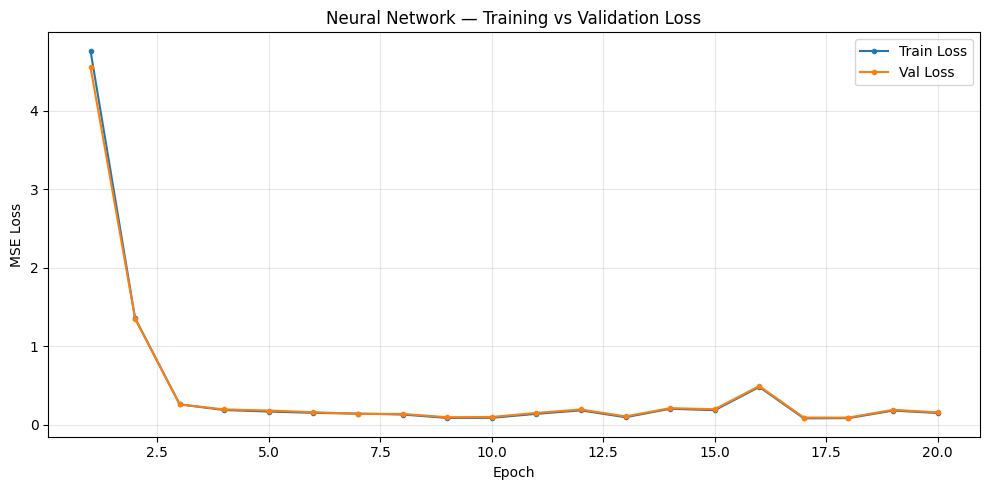

<Figure size 640x480 with 0 Axes>

In [77]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss", marker='o', markersize=3)
plt.plot(range(1, EPOCHS + 1), val_losses,   label="Val Loss",   marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Neural Network — Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')

#### Evaluation Metrics

In [89]:
#First evaluate model on the validation set

#Convert to new name from here on to avoid overwriting the variable
nn_model = model
nn_model.eval()

with torch.no_grad():
    preds = model(X_val_tensor).numpy()

y_true = Y_val_tensor.numpy()

mae = mean_absolute_error(y_true, preds)
rmse = np.sqrt(mean_squared_error(y_true, preds))
r2 = r2_score(y_true, preds)

print("Neural Network Performance (Validation Set)")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

Neural Network Performance (Validation Set)
MAE: 0.1883
RMSE: 0.3124
R2: 0.9934


## Part 3: Model Evaluation & Interpretation 

### Comprehensive Evaluation

In [165]:
#Evaluating Regression Models on Test Dataset
test_regression_results = []

for name, model in regressionModels.items():
    preds = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_regression_test, preds)
    rmse = np.sqrt(mean_squared_error(y_regression_test, preds))
    r2 = r2_score(y_regression_test, preds)

    test_regression_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

test_regression_results_df = pd.DataFrame(test_regression_results)


In [166]:
#Evaluating Neural Network For Regression
nn_model.eval()

all_preds = []
all_labels = []
with torch.no_grad(): 
    for X_batch, y_batch in test_loader: 
        pred = nn_model(X_batch)
        all_preds.append(pred)
        all_labels.append(y_batch)

all_preds  = torch.cat(all_preds).squeeze().numpy()   
all_labels = torch.cat(all_labels).squeeze().numpy()  

mae = mean_absolute_error(all_labels, all_preds)
rmse = np.sqrt(mean_squared_error(all_labels, all_preds))
r2 = r2_score(all_labels, all_preds)

test_regression_results_df.loc[len(test_regression_results_df)] = [
    "Neural Network",
    mae,
    rmse,
    r2
]


In [129]:
#Evaluating Classification Models on Test Dataset

#Add on the tuned model
classificationModels["Tuned Random Forrest"] = tuned_model

test_classification_results = []

for name, model in classificationModels.items():
    preds = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    accuracy = accuracy_score(y_classification_test, preds)
    precision = precision_score(y_classification_test, preds, zero_division=0)
    recall = recall_score(y_classification_test, preds, zero_division=0)
    f1 = f1_score(y_classification_test, preds, zero_division=0)
    auc_roc = roc_auc_score(y_classification_test, y_pred_proba)

    test_classification_results.append({
        "Model" : name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "AUC-ROC": auc_roc
    })

test_classification_results_df = pd.DataFrame(test_classification_results)

In [169]:
#Summary Table For Regression Models
test_regression_results_df

,Model,MAE,RMSE,R2
0,Linear Regression,0.074869,0.221310,0.996722
1,Random Forest Regressor,0.044129,0.522750,0.981710
2,Neural Network,0.188760,0.304774,0.993783


In [168]:
#Summary Table For Classification Models
test_classification_results_df

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.990704,0.990906,0.996906,0.993897,0.996441
1,Random Forest Classifier,0.981938,0.978641,0.997995,0.988223,0.998754
2,Tuned Random Forrest,0.981474,0.977883,0.998178,0.987926,0.998803


#### ROC Curve For Classification

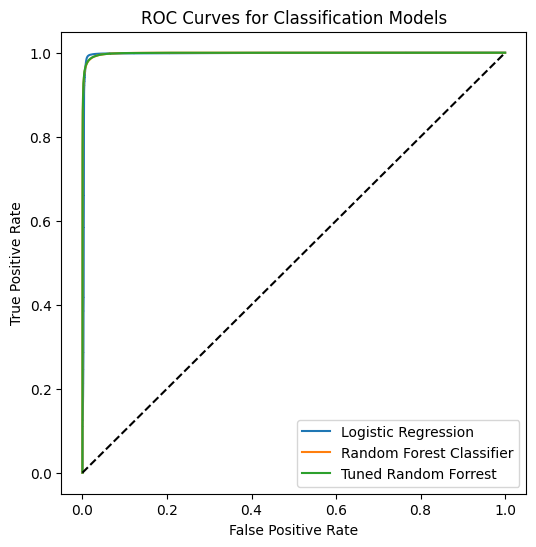

In [139]:
plt.figure(figsize=(6,6))

for name, model in classificationModels.items():

    probs = model.predict_proba(X_test_scaled)[:,1]

    fpr, tpr, _ = roc_curve(y_classification_test, probs)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Classification Models")
plt.legend()

plt.show()

#### Confusion Matrix For Best Model

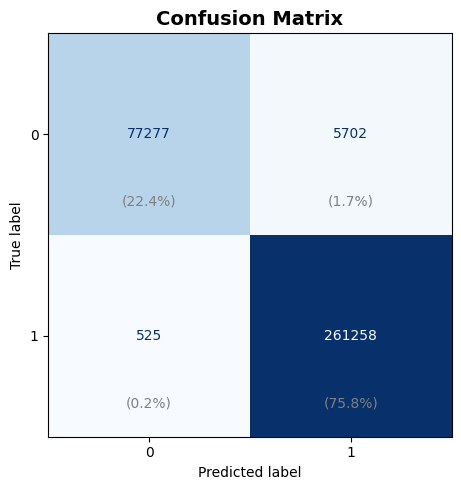

True Positives (high tip correct):  77277
False Negatives (high tip instead of low tip): 5702
False Positives (low tip instead of high tip): 525
True Negatives (low tip correct):   261258

False Positive Rate: 0.0687
False Negative Rate: 0.0020


In [147]:
best_classifier = randForestClassifierModel
y_pred = best_classifier.predict(X_test_scaled)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_classification_test, y_pred, ax=ax,
    cmap='Blues', colorbar=False
)

# Add percentage annotations
cm = confusion_matrix(y_classification_test, y_pred)
total = cm.sum()
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / total * 100
        ax.text(j, i + 0.3, f'({pct:.1f}%)', ha='center', va='top',
                fontsize=10, color='gray')


ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Error analysis
tn, fp, fn, tp = cm.ravel()
print(f'True Positives (high tip correct):  {tn}')
print(f'False Negatives (high tip instead of low tip): {fp}')
print(f'False Positives (low tip instead of high tip): {fn}')
print(f'True Negatives (low tip correct):   {tp}')
print(f'\nFalse Positive Rate: {fp/(fp+tn):.4f}')
print(f'False Negative Rate: {fn/(fn+tp):.4f}')

#### Scatter Plot For Regression Models (Random Forrest Regressor)

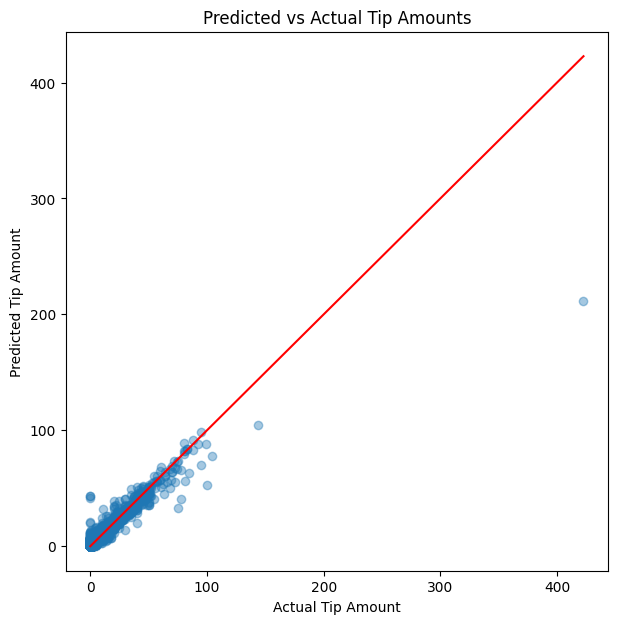

In [ ]:
best_regressor = randForestRegressModel

y_pred = best_regressor.predict(X_test_scaled)

plt.figure(figsize=(7,7))

plt.scatter(y_regression_test, y_pred, alpha=0.4)

plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")

plt.title("Predicted vs Actual Tip Amounts")

plt.plot([y_regression_test.min(), y_regression_test.max()],
         [y_regression_test.min(), y_regression_test.max()],
         color="red")

plt.show()

#### Residual Analysis of Best Regression Model (Random Forrest Regressor)

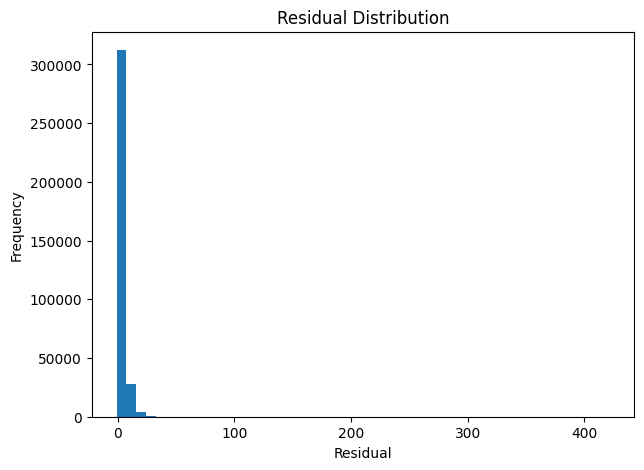

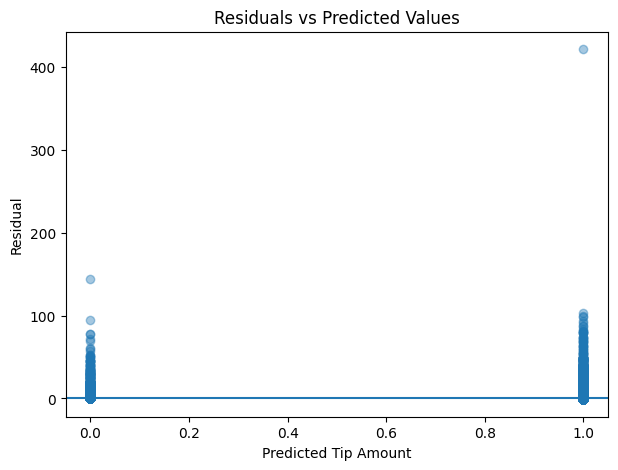

Residual Analysis — Best Regression Model (Random Forest)
  Mean Residual:     3.3723  (closer to 0 is better)
  Std of Residuals:  3.7584
  Min Residual:      -1.0000
  Max Residual:      421.7000
  % Within $1:       16.1%
  % Within $2:       44.7%


In [152]:
#We get the residuals (y_pred taken from previous cell)
residuals = y_regression_test - y_pred

#Residual distribution
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=50)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

#Residual vs Predicted Values
plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0)
plt.xlabel("Predicted Tip Amount")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.show()

print("Residual Analysis — Best Regression Model (Random Forest)")
print("=" * 55)
print(f"  Mean Residual:     {residuals.mean():.4f}  (closer to 0 is better)")
print(f"  Std of Residuals:  {residuals.std():.4f}")
print(f"  Min Residual:      {residuals.min():.4f}")
print(f"  Max Residual:      {residuals.max():.4f}")
print(f"  % Within $1:       {(abs(residuals) <= 1).mean()*100:.1f}%")
print(f"  % Within $2:       {(abs(residuals) <= 2).mean()*100:.1f}%")
print("=" * 55)

### Feature Importance

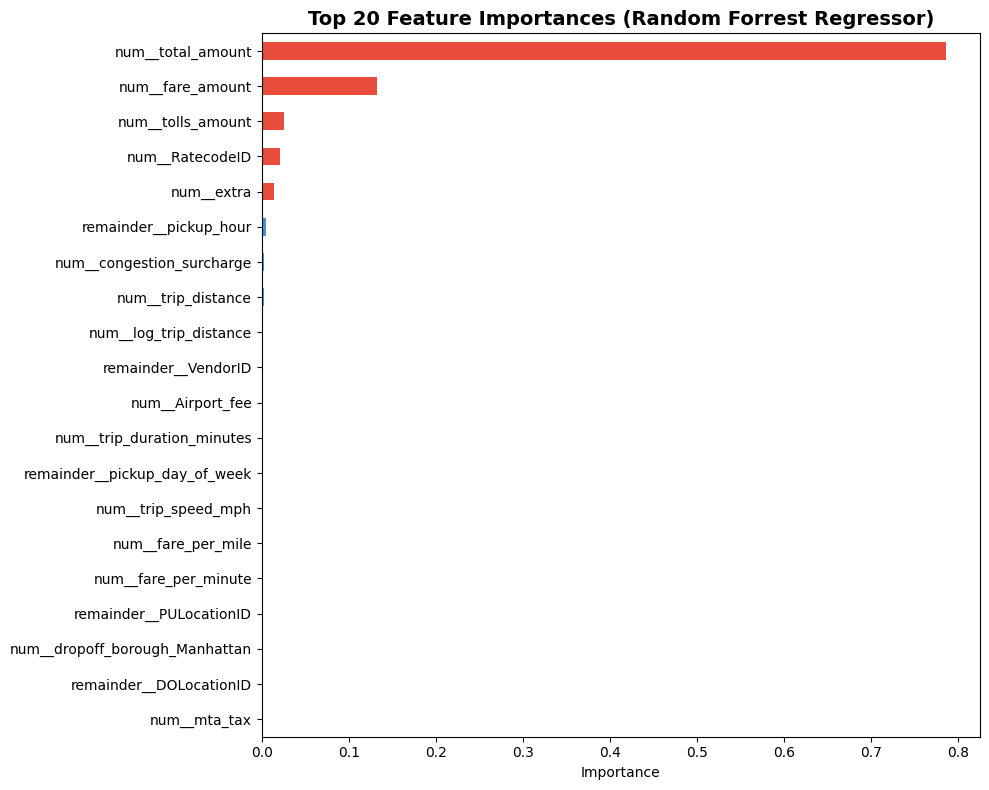

Top 10 Most Important Features:
 1. num__total_amount                   0.7855
 2. num__fare_amount                    0.1326
 3. num__tolls_amount                   0.0250
 4. num__RatecodeID                     0.0212
 5. num__extra                          0.0142
 6. remainder__pickup_hour              0.0053
 7. num__congestion_surcharge           0.0027
 8. num__trip_distance                  0.0019
 9. num__log_trip_distance              0.0016
10. remainder__VendorID                 0.0014


In [ ]:
# Extract importances from the Randfom Forrest Regression Model classifier
importances = randForestRegressModel.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot top 20 features
fig, ax = plt.subplots(figsize=(10, 8))
top_20 = feat_imp.head(20)
colors = ['#E74C3C' if x >= top_20.iloc[4] else '#4A90D9' for x in top_20.values]

top_20.sort_values().plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_title('Top 20 Feature Importances (Random Forrest Regressor)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 10 Most Important Features:')
print('=' * 45)
for i, (name, imp) in enumerate(feat_imp.head(10).items(), 1):
    print(f'{i:>2}. {name:<35s} {imp:.4f}')

#### Extracting Coefficients From Linear/Logistic Regression Models


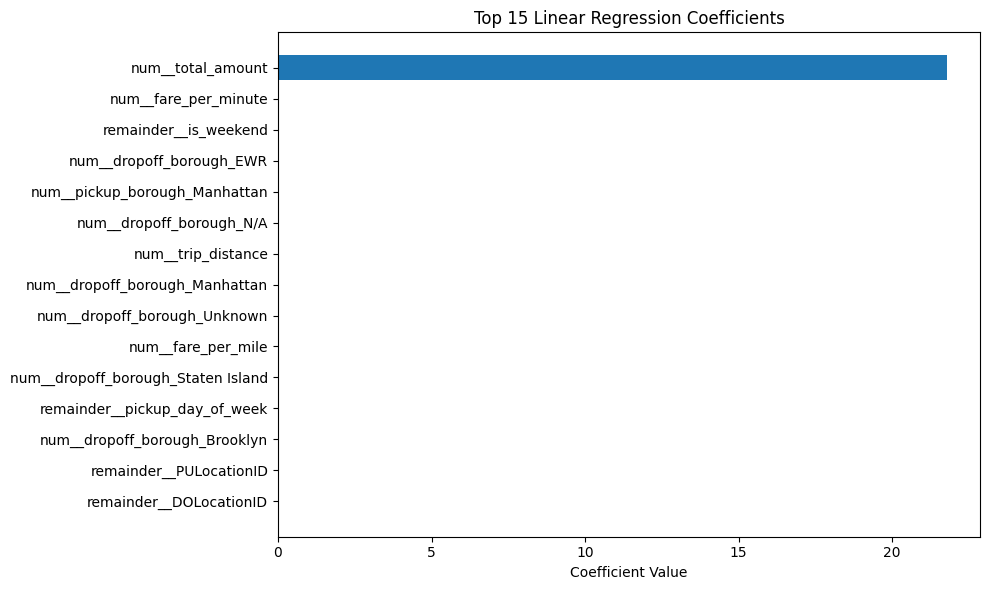

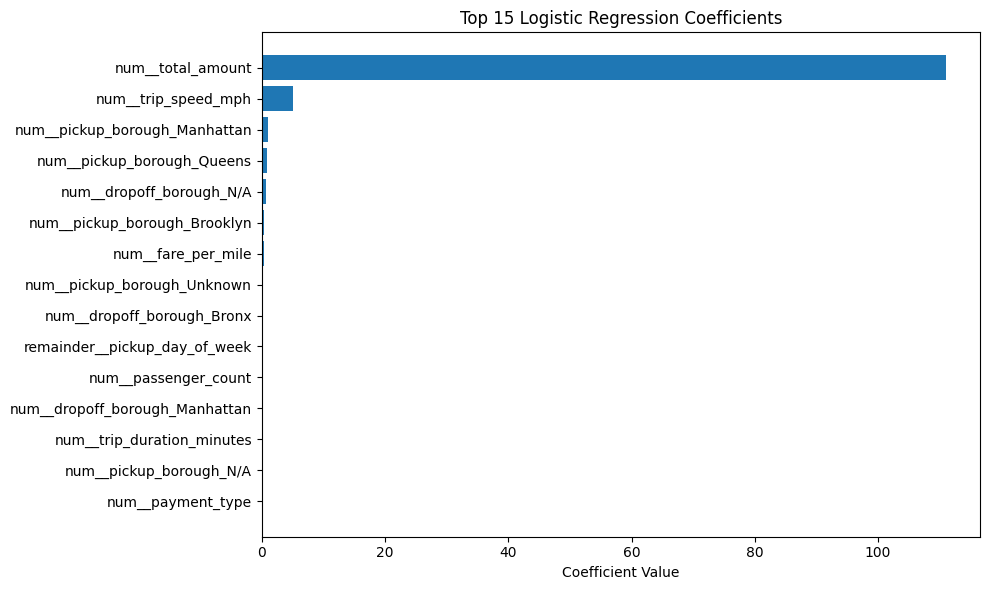

In [159]:
lin_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": linearRegressionModel.coef_
})

lin_coef_df = lin_coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

log_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": logisticRegressioModel.coef_[0]
})

log_coef_df = log_coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

# Linear Regression Coefficients
plt.figure(figsize=(10, 6))
plt.barh(
    lin_coef_df["Feature"][:15],
    lin_coef_df["Coefficient"][:15]
)
plt.gca().invert_yaxis()
plt.xlabel("Coefficient Value")
plt.title("Top 15 Linear Regression Coefficients")
plt.tight_layout()
plt.show()

# Logistic Regression Coefficients
plt.figure(figsize=(10, 6))
plt.barh(
    log_coef_df["Feature"][:15],
    log_coef_df["Coefficient"][:15]
)
plt.gca().invert_yaxis()
plt.xlabel("Coefficient Value")
plt.title("Top 15 Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

Looking at the above charts the total amount was the most important coefficients, this may be due to data leakage as the tip amount is included in the total amount. Because of this it would be important to drop these columns on re training the models to get a better grasp and models for predicting the tip amount.

#### SHAP Values

C:\Users\arves\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


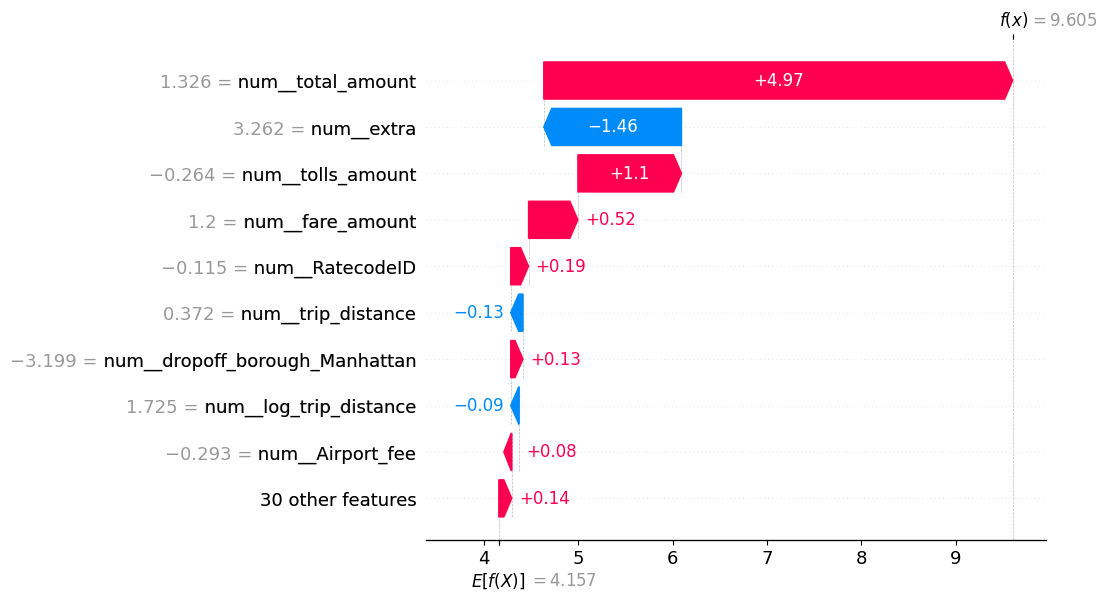

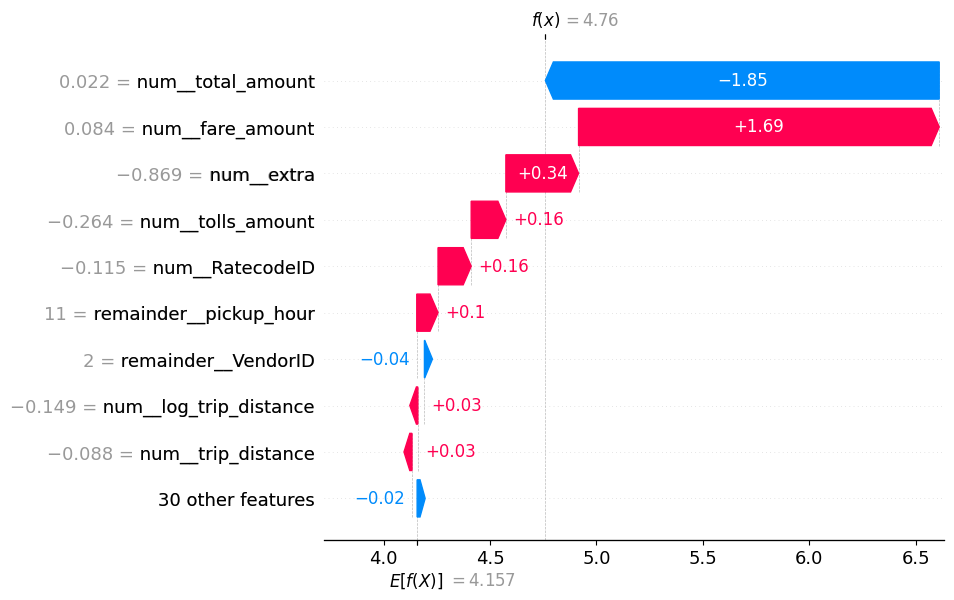

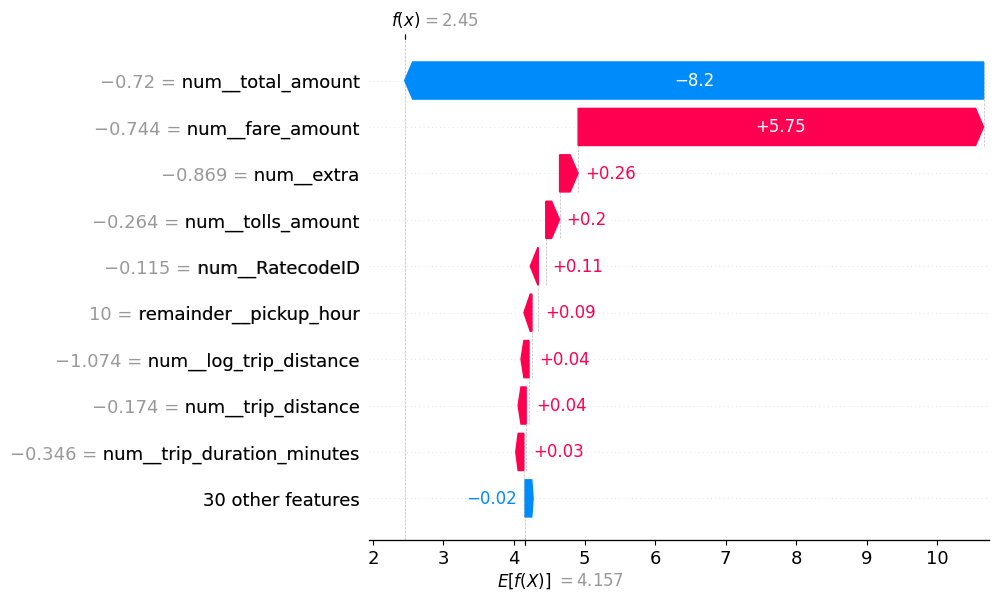

In [ ]:

explainer = shap.Explainer(randForestRegressModel)

shap_values = explainer(X_test_scaled[:100])

for i in range(3):
    shap.plots.waterfall(shap_values[i])

### Written Analysis

### a) Which model performed best for each task and why

Random Forest performed better because it is better at handling non linear data. Taxi tipping behaviour is influenced by many factors such as trip distance, fare amount, and time of day which form non linear relationships. Linear Regression assumes a linear relationship between the features and the target variable which will perform worse. The Random Forest model, however, use of decision trees, allowing it to learn interactions between features and handle nonlinear dependencies.

For the classification task, the models evaluated were Logistic Regression and Random Forest Classifier. The Random Forest Classifier achieved the highest performance across several metrics including accuracy, F1-score, and AUC-ROC. This again suggests that tipping behaviour depends on complex interactions between multiple features, which tree-based ensemble models are better suited to capture compared to simpler linear models.

In summary, the Random Forest models performed the best due to a non linear relationship being modelled for the taxi data with regards to tip amount and the classification of it being a high tip as the tip given in a taxi ride can be modelled by many variables.

### b) Most predictive features for tip amount

The fare amount would be the major factor in predicting the tip amount however in the models trained there was data leakage in the total amount which lead to inaccuracies in the important features.

Other factors such as the trip distance and duration would also affect the tip amount with trips over a longer distance yielding larger tips.

Temporal features such as pickup hour and whether the trip occurred on a weekend also contributed to the predictions. This may reflect changes in passenger behaviour during peak travel times or weekends when passengers may be more likely to tip.


### c) Limitations of the models

The major flaw with our current model is the data leakage caused from leaving the total amount in the training data. This allowed the model to cheat and guess the tip amount from this column.

Any fare related features will also greatly affect this model as it will rely heavily on them to make predictions which can lead to the model being trained poorly.

Another limitation is that the dataset only includes credit card payments, since tip information is reliably recorded only for those transactions. This may introduce bias because tipping behaviour for cash payments is not represented in the dataset.

The models are also limited by the available features. Important factors such as passenger demographics, weather conditions, or driver service quality are not included in the dataset but could significantly influence tipping behaviour.


### d) Potential improvements

The first major improvement would be to remove all fare related features (mainly the total amount) to avoid any reliance from the model on these features leading to a poorly trained model that performs badly on other datasets.

The hyper parameter tuning can also be done on more parameters with larger ranges being given for the model to choose from. With our current tuning we got a worse model than we started with. This occurred due to time limitations and hardware constraints.

Using external data sources could also improve the models. For example, weather data, traffic conditions, or special events in the city could influence tipping behaviour.


### e) Neural networks vs traditional ML models

The neural network model performed reasonably well but did not significantly outperform the Random Forest model. This outcome occurred because neural networks typically perform best on very high-dimensional data such as images, text, or audio. In contrast, this problem involves structured tabular data, where tree-based models such as Random Forest or Gradient Boosting often perform better.

A neural network also requires much more extensive tuning of hyper parameters. Without this the model will be sub par to pre existing ones.

In this project, the Random Forest model provided a strong balance of predictive performance, robustness, and interpretability, making it particularly well suited for this type of problem. However, the neural network still demonstrated that deep learning methods can be applied to tabular prediction tasks and provided a useful comparison to traditional machine learning approaches.

## Auxillary Code to Load Models

In [ ]:
#Code to Load Models
linearRegressionModel     = joblib.load('models/linear_regression.joblib')
randForestRegressModel    = joblib.load('models/rf_regressor.joblib')
logisticRegressioModel    = joblib.load('models/logistic_regression.joblib')
randForestClassifierModel = joblib.load('models/rf_classifier_baseline.joblib')
tuned_model                = joblib.load('models/tuned_model.joblib')

print("✓ All models loaded")

✓ All models loaded


In [ ]:
# Load model For Neural Network
checkpoint = torch.load('models/nn_regressor.pth')

# Recreate architecture using saved config
model = TipPredictor(checkpoint['input_size'])
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("✓ Neural network loaded")
print(f"  Input size: {checkpoint['input_size']}")
print(f"  Hidden sizes: {checkpoint['hidden_sizes']}")

✓ Neural network loaded
  Input size: 39
  Hidden sizes: [128, 64]


## AI Tools Used


ChatGPT along with Deepseek, and Claude was used in completing this assignment for information on python syntax and code for the assignment.

Features which both models helped with were:
- Syntax for Scikit Learn
- Help with understanding the models and how to use them
- Help with training models
- Help with training the neural network for a regression problem instead
- Creation of graphs and presenting the data
- Understanding what is needed for the different scorings
- Creating README and getting version numbers for requirements.txt